In [1]:
from find_smooth_submanifold import *
import jax
import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np

Note 1: Here we will just pick one patch. For a set of three equations, it is common that the error is smaller on patch but large on another patch. But the key is that since we are all using homogeneous coordinates, we can always find an equivalent set of equations so that it reprents the same submainfold, but error is small on the patch we choose.

Note 2: Since the points on the quintic is sampled with respected to the Fubini-Study metric, certain regions have more points in it, making it easier for find points with small loss in that region. It is possible that the search will be skewed towards those regions. (RP^3 is slightly more concentrated but does not have the largest volume.) This issue is not very easy to deal with, so far we just ignore it and hope it won't affect the result too much. (in a sense that even though it is easier to certain regions, it is still likely to find solutions in other parts, unless the points are supper sparse.)

In [33]:
with open('/home/spencer/Documents/SLagSearch/5mil_patch0.pkl', 'rb') as f:
    pts_5mil_patch0 = pickle.load(f)

In [34]:
pts_5mil_patch0 = jnp.asarray(pts_5mil_patch0)
basis = generate_basis(pts_5mil_patch0)

In [4]:
pts_5mil_patch0.shape

(1001166, 5)

In [35]:
seed = 42

# Initialize coefficients with focus on imaginary cross terms
key = jax.random.PRNGKey(seed)
    
# Start with random initialization
coeffs_random = jax.random.uniform(key, (5, 3, 25), minval=-1, maxval=1)

In [6]:
coeffs_random

Array([[[ 0.7891462 , -0.47037077,  0.07370639,  0.5716653 ,
         -0.2991979 ,  0.02542639, -0.12302423,  0.7885597 ,
          0.27932644,  0.417511  , -0.6040611 ,  0.20207238,
         -0.29690862, -0.24576116, -0.36475468,  0.25872755,
          0.8984797 , -0.8867457 ,  0.6850662 , -0.9402423 ,
         -0.7206404 , -0.94962406,  0.8841858 ,  0.13026452,
         -0.8900173 ],
        [-0.55589867,  0.9924865 , -0.386482  ,  0.8782227 ,
         -0.48933554,  0.9956467 , -0.8349912 , -0.7555351 ,
         -0.11701608, -0.1413641 , -0.06683707,  0.38429976,
         -0.5972009 ,  0.8285005 , -0.85175943, -0.32856774,
         -0.7482171 ,  0.75578403, -0.09115481, -0.5960405 ,
         -0.1946137 ,  0.7541685 , -0.47362947, -0.4433179 ,
         -0.5536866 ],
        [-0.25162816,  0.00200558,  0.7763598 ,  0.82897115,
         -0.3713634 ,  0.5999646 , -0.46597672, -0.90355253,
         -0.5324297 ,  0.8561382 ,  0.17087555, -0.34863997,
         -0.5198128 , -0.9943564 ,  0.9

In [ ]:
coeffs_RP3 = jnp.zeros((3, 25)).at[[0, 1, 2], [0, 1, 2]].set(1)
coeffs_T3 = jnp.zeros((3, 25)).at[[0, 1, 2], [10, 15, 19]].set(1).at[[0, 1, 2],[15, 19, 22]].set(-1)

In [8]:
coeffs_T3

Array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0., -1.,  0.,  0.]],      dtype=float32)

In [9]:
coeffs_simple = jnp.zeros((3, 25)).at[[0, 0, 0, 1, 1, 2], [3, 5, 6, 11, 12, 13]].set(1)
coeffs_simple2 = jnp.zeros((3, 25)).at[[0, 0, 0, 1, 1, 2, 2], [0, 1, 5, 2, 4, 21, 23]].set(1)
coeffs_simple3 = jnp.zeros((3, 25)).at[[0, 1, 2], [0, 1, 13]].set(1)

In [10]:
labels = np.array(get_basis_labels())

In [11]:
print(labels[[3, 5, 6, 11, 12, 13]])
print(labels[[0, 1, 5, 2, 4, 21, 23]])
print(labels[[0,1,13]])

['Im(z0*z4bar)' 'Im(z1*z3bar)' 'Im(z1*z4bar)' 'Re(z0*z1bar)'
 'Re(z0*z2bar)' 'Re(z0*z3bar)']
['Im(z0*z1bar)' 'Im(z0*z2bar)' 'Im(z1*z3bar)' 'Im(z0*z3bar)'
 'Im(z1*z2bar)' 'Re(z2*z4bar)' 'Re(z3*z4bar)']
['Im(z0*z1bar)' 'Im(z0*z2bar)' 'Re(z0*z3bar)']


In [12]:
labels

array(['Im(z0*z1bar)', 'Im(z0*z2bar)', 'Im(z0*z3bar)', 'Im(z0*z4bar)',
       'Im(z1*z2bar)', 'Im(z1*z3bar)', 'Im(z1*z4bar)', 'Im(z2*z3bar)',
       'Im(z2*z4bar)', 'Im(z3*z4bar)', 'Re(z0*z0bar)', 'Re(z0*z1bar)',
       'Re(z0*z2bar)', 'Re(z0*z3bar)', 'Re(z0*z4bar)', 'Re(z1*z1bar)',
       'Re(z1*z2bar)', 'Re(z1*z3bar)', 'Re(z1*z4bar)', 'Re(z2*z2bar)',
       'Re(z2*z3bar)', 'Re(z2*z4bar)', 'Re(z3*z3bar)', 'Re(z3*z4bar)',
       'Re(z4*z4bar)'], dtype='<U12')

In [13]:
print(labels[[10, 15, 19, 22]])

['Re(z0*z0bar)' 'Re(z1*z1bar)' 'Re(z2*z2bar)' 'Re(z3*z3bar)']


In [ ]:
coeffs_RP3 = normalize_coeffs(coeffs_RP3)
coeffs_T3 = normalize_coeffs(coeffs_T3)
coeffs_simple = normalize_coeffs(coeffs_simple)
coeffs_simple2 = normalize_coeffs(coeffs_simple2)
coeffs_simple3 = normalize_coeffs(coeffs_simple3)
for i in range(5):
    coeffs_random = coeffs_random.at[i].set(normalize_coeffs(coeffs_random[i]))

In [ ]:
loss_RP3_list = []
loss_T3_list = []
loss_random1_list = []
loss_random2_list = []
loss_random3_list = []
loss_random4_list = []
loss_random5_list = []
loss_simple1_list = []
loss_simple2_list = []
loss_simple3_list = []

for k in range(1, 1000, 20):
    loss_RP3_list.append(loss_function(coeffs_RP3, basis, k=k, lambda_reg=0))
    loss_T3_list.append(loss_function(coeffs_T3, basis, k=k, lambda_reg=0))
    loss_random1_list.append(loss_function(coeffs_random[0], basis, k=k, lambda_reg=0))
    loss_random2_list.append(loss_function(coeffs_random[1], basis, k=k, lambda_reg=0))
    loss_random3_list.append(loss_function(coeffs_random[2], basis, k=k, lambda_reg=0))
    loss_random4_list.append(loss_function(coeffs_random[3], basis, k=k, lambda_reg=0))
    loss_random5_list.append(loss_function(coeffs_random[4], basis, k=k, lambda_reg=0))
    loss_simple1_list.append(loss_function(coeffs_simple, basis, k=k, lambda_reg=0))
    loss_simple2_list.append(loss_function(coeffs_simple2, basis, k=k, lambda_reg=0))
    loss_simple3_list.append(loss_function(coeffs_simple3, basis, k=k, lambda_reg=0))

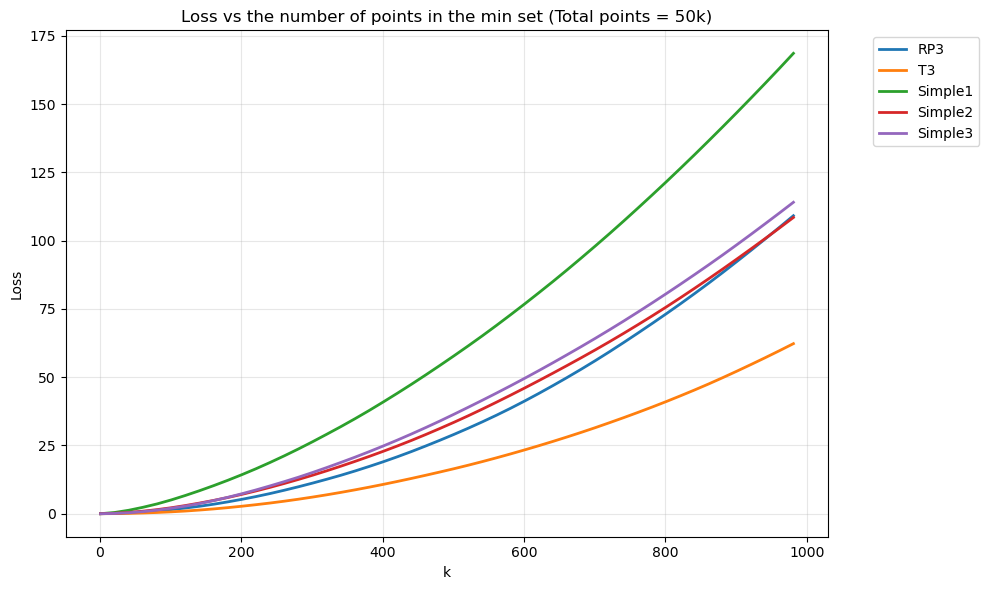

In [27]:
# Create figure and axis
plot_random = False
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(1, 1000, 20)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3_list, label='RP3', linewidth=2)
plt.plot(x, loss_T3_list, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple1_list, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2_list, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3_list, label='Simple3', linewidth=2)

# Plot random losses
if plot_random:
    plt.plot(x, loss_random1_list, label='Random1', linewidth=2)
    plt.plot(x, loss_random2_list, label='Random2', linewidth=2)
    plt.plot(x, loss_random3_list, label='Random3', linewidth=2)
    plt.plot(x, loss_random4_list, label='Random4', linewidth=2)
    plt.plot(x, loss_random5_list, label='Random5', linewidth=2)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss')
#plt.yscale('log')
plt.title('Loss vs the number of points in the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('loss_vs_k_1mil_without_random.png')
plt.show()

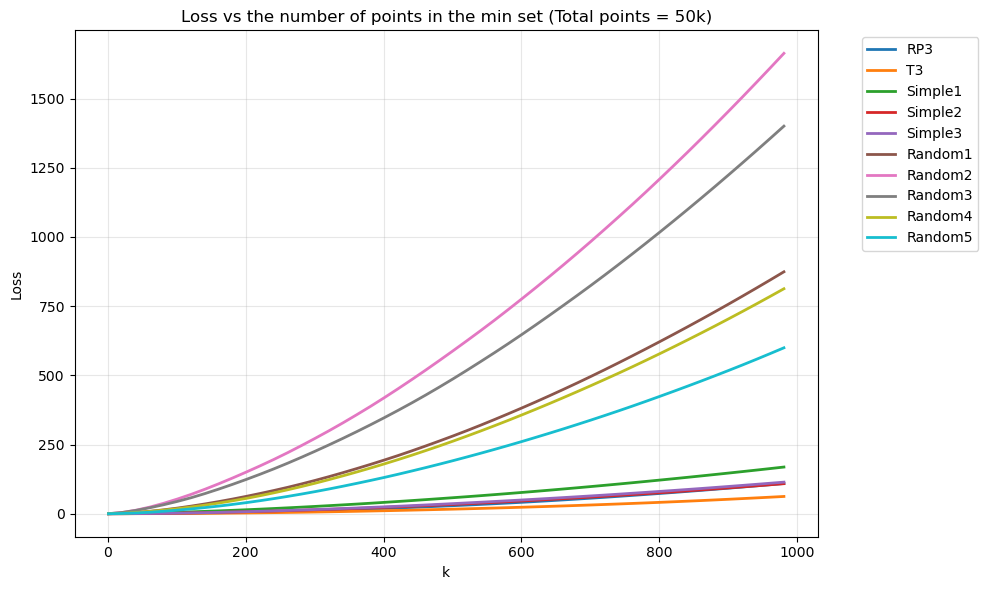

In [28]:
# Create figure and axis
plot_random = True
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(1, 1000, 20)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3_list, label='RP3', linewidth=2)
plt.plot(x, loss_T3_list, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple1_list, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2_list, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3_list, label='Simple3', linewidth=2)

# Plot random losses
if plot_random:
    plt.plot(x, loss_random1_list, label='Random1', linewidth=2)
    plt.plot(x, loss_random2_list, label='Random2', linewidth=2)
    plt.plot(x, loss_random3_list, label='Random3', linewidth=2)
    plt.plot(x, loss_random4_list, label='Random4', linewidth=2)
    plt.plot(x, loss_random5_list, label='Random5', linewidth=2)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss')
#plt.yscale('log')
plt.title('Loss vs the number of points in the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('loss_vs_k_1mil_with_random.png')
plt.show()

In [36]:
k = 1000
loss_RP3 = loss_function_array(coeffs_RP3, basis, k=k)
loss_T3 = loss_function_array(coeffs_T3, basis, k=k)
loss_random = []
for i in range(5):
    loss_rand = loss_function_array(coeffs_random[i], basis, k=k)
    loss_random.append(loss_rand)
    
loss_simple = loss_function_array(coeffs_simple, basis, k=k)    
loss_simple2 = loss_function_array(coeffs_simple2, basis, k=k)
loss_simple3 = loss_function_array(coeffs_simple3, basis, k=k)

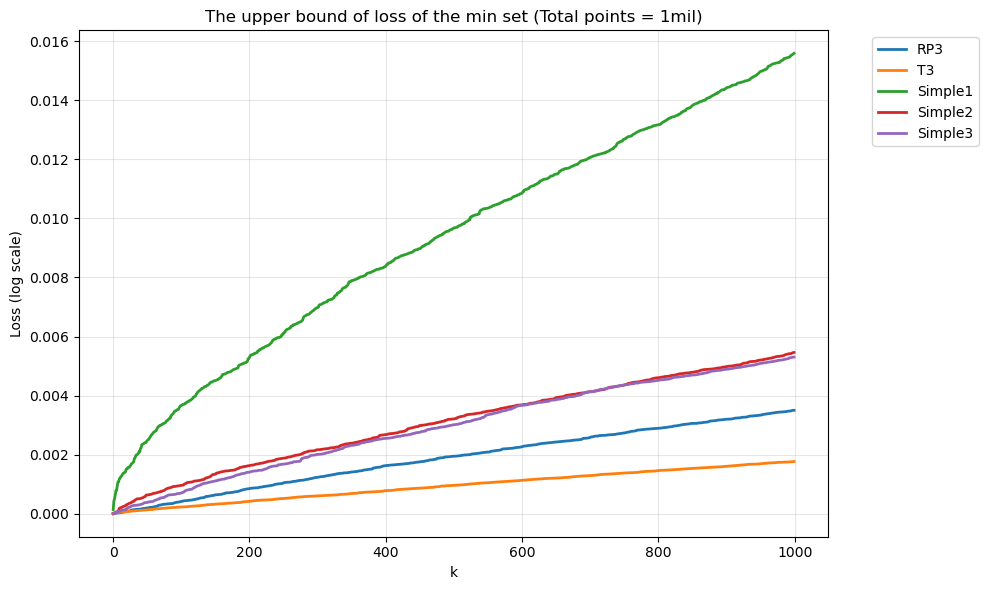

In [37]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(k)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_T3, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3, label='Simple3', linewidth=2)

# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss (log scale)')
#plt.yscale('log')
plt.title('The upper bound of loss of the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('upper_bound_1mil_without_random.png')
plt.show()

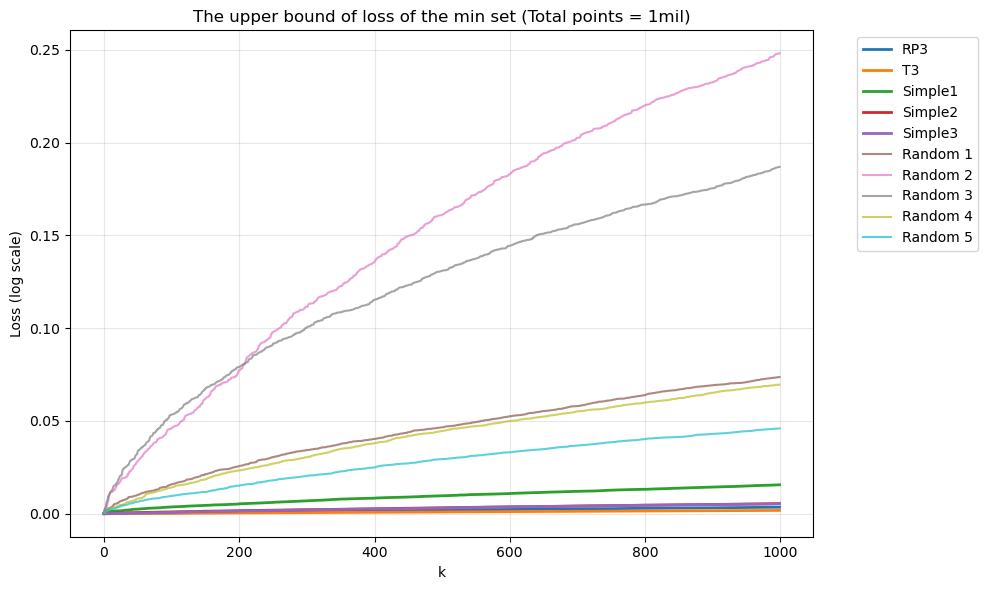

In [38]:
# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot each loss curve
x = np.arange(k)  # x-axis values from 0 to k-1

# Plot RP3 loss
plt.plot(x, loss_RP3, label='RP3', linewidth=2)
plt.plot(x, loss_T3, label='T3', linewidth=2)

# Plot simple losses
plt.plot(x, loss_simple, label='Simple1', linewidth=2)
plt.plot(x, loss_simple2, label='Simple2', linewidth=2)
plt.plot(x, loss_simple3, label='Simple3', linewidth=2)

# Plot random losses
for i in range(5):
    plt.plot(x, loss_random[i], label=f'Random {i+1}', alpha=0.7)



# Add labels and title
plt.xlabel('k')
plt.ylabel('Loss (log scale)')
#plt.yscale('log')
plt.title('The upper bound of loss of the min set (Total points = 1mil)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
plt.savefig('upper_bound_1mil_with_random.png')
plt.show()

In [40]:
# Main execution
if __name__ == "__main__":
 
    # points = jnp.array(np.load("fermat_quintic_points.npy"))

    
    # Optimize equations
    print("\nOptimizing equations...")
    coeffs, losses = optimize_equations(
        pts_5mil_patch0, 
        learning_rate=0.01, 
        num_steps=3000,
        lambda_reg=0.1
    )
    
    # Analyze solution
   # analyze_solution(coeffs, points)
    
    # Save results
    #np.save("optimized_coefficients.npy", np.array(coeffs))
    #print("\nCoefficients saved to 'optimized_coefficients.npy'")


Optimizing equations...


TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
#TODO: Actually optimize the random equations
#DONE: Update on one patch only, name the plots correctly
#DONE: Reweight the points by det g of the fubini-Study metric (Double check which metric we should use)